# Nama : I Made Bimantoro Mastra
# Assignment : Advanced Exploratory Data Analysis Techniques in Python



---


## A. Import Data

In [ ]:
# Import library.
import pandas as pd               # Untuk baca & olah data tabular (dataframe).
import numpy as np                # Untuk operasi numerik (angka, NaN, dll).
import matplotlib.pyplot as plt   # Untuk membuat grafik dasar.
import seaborn as sns             # Untuk membuat grafik statistik yang lebih bagus & mudah.

%matplotlib inline
sns.set_style('whitegrid')

# Baca dataset dari file csv
df = pd.read_csv('/content/sample_data/Telco_customer_churn.csv')

print("✅ All libraries and datasets loaded!")


✅ All libraries and datasets loaded!


In [ ]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices




---


## B. Data Understanding

In [ ]:
df.shape

(7043, 33)

Dataset ini punya 7043 baris (pelanggan) dan 33 kolom (atribut).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


**INSIGHT dari `describe()` kolom numerik:**
- `Tenure Months` berkisar 0-72 bulanr.
- `Churn Score` (skor risiko churn, dibuat oleh sistem) berkisar dari sekitar 5 sampai 100.
- `CLTV` (prediksi nilai jangka panjang pelanggan) rata-rata sekitar 4400, dengan rentang cukup lebar.
- `Count` cuma berisi angka 1 di semua baris -- kolom ini tidak berguna untuk analisis, akan dibuang di tahap feature engineering.

In [ ]:
df.describe(include='object')

,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Total Charges,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043,7043,1869
unique,7043,1,1,1129,1652,2,2,2,2,2,...,3,3,3,3,3,2,4,6531,2,20
top,3186-AJIEK,United States,California,Los Angeles,"34.159534, -116.425984",Male,No,No,No,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No,Attitude of support person
freq,1,7043,7043,305,5,3555,5901,3641,5416,6361,...,3095,3473,2810,2785,3875,4171,2365,11,5174,192


**INSIGHT dari kolom kategorikal:**
- `Country` cuma punya 1 nilai unik (United States) dan `State` cuma California, tidak memberi variasi informasi jadi didibuang.
- `City` punya banyak nilai unik (lebih dari 1000 kota berbeda), ini bisa dipakai untuk analisis churn per wilayah.
- `Churn Reason` adalah kolom baru yang berisi alasan spesifik pelanggan churn ini sangat berguna untuk dianalisis.

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


**INSIGHT:** Kolom `Churn Reason` punya 5174 nilai kosong (NaN).

In [ ]:
df.nunique()

,0
CustomerID,7043
Count,1
Country,1
State,1
City,1129
Zip Code,1652
Lat Long,1652
Latitude,1652
Longitude,1651
Gender,2


In [ ]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


In [ ]:
df['Churn Label'].value_counts(normalize=True) * 100

,proportion
Churn Label,
No,73.463013
Yes,26.536987


Sekitar 73% pelanggan tidak churn dan 27% churn(data imbalanced).

In [ ]:
# Cek konsistensi antara Churn Label dan Churn Value.
pd.crosstab(df['Churn Label'], df['Churn Value'])

Churn Value,0,1
Churn Label,,
No,5174,0
Yes,0,1869


Terkonfirmasi `Churn Label` (Yes/No) dan `Churn Value` (1/0) selalu sinkron, jadi keduanya menyatakan informasi yang sama persis.



---


## C. Feature Engineering

### C.1 Buang kolom yang tidak berguna untuk analisis

`Count` (selalu 1), `Country` (selalu United States), dan `State` (selalu California) tidak memberi variasi informasi apapun, jadi kita buang. `Lat Long`, `Latitude`, `Longitude` juga kita buang karena analisis lokasi cukup pakai `City` saja.

In [ ]:
kolom_dibuang = ['Count', 'Country', 'State', 'Lat Long', 'Latitude', 'Longitude', 'Zip Code']
df = df.drop(columns=kolom_dibuang)

df.columns.tolist()

['CustomerID',
 'City',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

### C.2 Investigasi kolom `Total Charges`

`Total Charges` bertipe object padahal seharusnya numerik.

In [ ]:
total_charges_numeric = pd.to_numeric(df['Total Charges'], errors='coerce')

# Cek baris yang gagal diubah
df[total_charges_numeric.isnull()][['CustomerID', 'Tenure Months', 'Monthly Charges', 'Total Charges']]

,CustomerID,Tenure Months,Monthly Charges,Total Charges
2234,4472-LVYGI,0,52.55,
2438,3115-CZMZD,0,20.25,
2568,5709-LVOEQ,0,80.85,
2667,4367-NUYAO,0,25.75,
2856,1371-DWPAZ,0,56.05,
4331,7644-OMVMY,0,19.85,
4687,3213-VVOLG,0,25.35,
5104,2520-SGTTA,0,20.00,
5719,2923-ARZLG,0,19.70,
6772,4075-WKNIU,0,73.35,


`Tenure Months = 0` yang `Total Charges`-nya kosong (pelanggan baru, belum ada tagihan) tetap diisi dengan 0.

In [ ]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(0)

df['Total Charges'].dtype

dtype('float64')

### C.3 Cek data duplikat

In [ ]:
print('Baris duplikat penuh:', df.duplicated().sum())
print('CustomerID duplikat:', df['CustomerID'].duplicated().sum())

Baris duplikat penuh: 0
CustomerID duplikat: 0


### C.4 Rapikan kategori "No internet service" / "No phone service"

In [ ]:
kolom_layanan = ['Online Security', 'Online Backup', 'Device Protection',
                  'Tech Support', 'Streaming TV', 'Streaming Movies']

for kolom in kolom_layanan:
    df[kolom] = df[kolom].replace('No internet service', 'No')

df['Multiple Lines'] = df['Multiple Lines'].replace('No phone service', 'No')

df['Online Security'].unique()

array(['Yes', 'No'], dtype=object)

### C.5 Simulasi kolom datetime: `JoinDate`



In [ ]:
tanggal_data_ditarik = pd.Timestamp('2024-01-01')

df['JoinDate'] = df['Tenure Months'].apply(lambda bulan: tanggal_data_ditarik - pd.DateOffset(months=int(bulan)))
df['JoinYearMonth'] = df['JoinDate'].dt.to_period('M')

df[['CustomerID', 'Tenure Months', 'JoinDate', 'JoinYearMonth']].head()

,CustomerID,Tenure Months,JoinDate,JoinYearMonth
0,3668-QPYBK,2,2023-11-01,2023-11
1,9237-HQITU,2,2023-11-01,2023-11
2,9305-CDSKC,8,2023-05-01,2023-05
3,7892-POOKP,28,2021-09-01,2021-09
4,0280-XJGEX,49,2019-12-01,2019-12


### C.6 Buat kolom kelompok tenure (`TenureGroup`)

In [ ]:
batas_bin = [0, 12, 24, 48, 72]
label_bin = ['0-12 bulan', '13-24 bulan', '25-48 bulan', '49-72 bulan']

df['TenureGroup'] = pd.cut(df['Tenure Months'], bins=batas_bin, labels=label_bin, include_lowest=True)

df['TenureGroup'].value_counts()

,count
TenureGroup,
49-72 bulan,2239
0-12 bulan,2186
25-48 bulan,1594
13-24 bulan,1024


### C.7 Buat kolom `JumlahLayananTambahan`

In [ ]:
df['JumlahLayananTambahan'] = (df[kolom_layanan] == 'Yes').sum(axis=1)

df[['CustomerID'] + kolom_layanan + ['JumlahLayananTambahan']].head()

,CustomerID,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,JumlahLayananTambahan
0,3668-QPYBK,Yes,Yes,No,No,No,No,2
1,9237-HQITU,No,No,No,No,No,No,0
2,9305-CDSKC,No,No,Yes,No,Yes,Yes,3
3,7892-POOKP,No,No,Yes,Yes,Yes,Yes,4
4,0280-XJGEX,No,Yes,Yes,No,Yes,Yes,4


### C.8 Kelompokkan `Churn Reason` jadi kategori yang lebih besar

`Churn Reason` punya banyak nilai unik yang spesifik ("Competitor offered higher download speeds", "Attitude of support person"). Dikelompokkan jadi beberapa kategori besar biar lebih mudah dianalisis.

In [ ]:
df['Churn Reason'].value_counts()

,count
Churn Reason,
Attitude of support person,192
Competitor offered higher download speeds,189
Competitor offered more data,162
Don't know,154
Competitor made better offer,140
Attitude of service provider,135
Competitor had better devices,130
Network reliability,103
Product dissatisfaction,102


In [ ]:
def kelompokkan_alasan(alasan):
    if pd.isnull(alasan):
        return 'Tidak churn'
    alasan_lower = alasan.lower()
    if 'competitor' in alasan_lower:
        return 'Kompetitor'
    elif 'attitude' in alasan_lower or 'service' in alasan_lower or 'support' in alasan_lower:
        return 'Layanan/Sikap Staff'
    elif 'price' in alasan_lower or 'charge' in alasan_lower:
        return 'Harga'
    elif 'network' in alasan_lower or 'product' in alasan_lower:
        return 'Kualitas Produk/Jaringan'
    elif 'moved' in alasan_lower:
        return 'Pindah Domisili'
    else:
        return 'Lainnya'

df['ChurnReasonGroup'] = df['Churn Reason'].apply(kelompokkan_alasan)

df['ChurnReasonGroup'].value_counts()

,count
ChurnReasonGroup,
Tidak churn,5174
Kompetitor,621
Layanan/Sikap Staff,587
Kualitas Produk/Jaringan,205
Lainnya,204
Harga,199
Pindah Domisili,53


**Ringkasan Feature Engineering:**
1. Buang kolom yang tidak informatif: `Count`, `Country`, `State`, `Lat Long`, `Latitude`, `Longitude`, `Zip Code`.
2. `Total Charges` diubah ke numerik, 11 nilai kosong diisi 0.
3. Kategori "No internet/phone service" diseragamkan jadi "No".
4. `JoinDate` & `JoinYearMonth` dibuat sebagai simulasi kolom datetime dari `Tenure Months`.
5. `TenureGroup` dibuat untuk mengelompokkan lama berlangganan.
6. `JumlahLayananTambahan` dibuat untuk menghitung banyaknya layanan tambahan yang dipakai.
7. `ChurnReasonGroup` dibuat untuk mengelompokkan alasan churn yang detail jadi kategori besar.



---


## D. Pertanyaan Analisis

Pertanyaan bisnis yang akan dijawab berdasarkan teknik data manipulation (sorting, filtering, groupby, pivot, crosstab, melt, dan datetime):

1. Bagaimana perbandingan tingkat churn antar jenis kontrak (Contract)?
2. Apakah metode pembayaran (Payment Method) berhubungan dengan kecenderungan pelanggan churn?
3. Bagaimana pola churn berdasarkan kelompok lama berlangganan (TenureGroup), dan bagaimana trennya dari waktu ke waktu (simulasi JoinDate)?
4. Apakah jumlah layanan tambahan yang dipakai pelanggan berhubungan dengan churn rate?
5. Apa alasan utama (Churn Reason) pelanggan berhenti berlangganan, dan bagaimana hubungannya dengan CLTV serta kota asal pelanggan?

## Pertanyaan 1: Bagaimana perbandingan tingkat churn antar jenis kontrak (Contract)?

Teknik: **crosstab** dan **sorting**.

In [ ]:
tabel_kontrak = pd.crosstab(df['Contract'], df['Churn Label'], normalize='index') * 100
tabel_kontrak = tabel_kontrak.sort_values(by='Yes', ascending=False)
tabel_kontrak

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


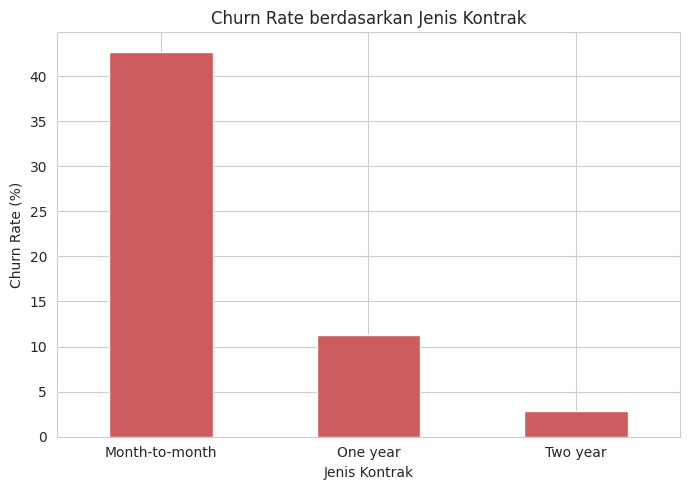

In [ ]:
plt.figure(figsize=(7, 5))
tabel_kontrak['Yes'].plot(kind='bar', color='indianred')
plt.title('Churn Rate berdasarkan Jenis Kontrak')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Jenis Kontrak')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**INSIGHT Pertanyaan 1:**
Pelanggan dengan kontrak **Month-to-month** punya churn rate jauh lebih tinggi dibanding kontrak One year maupun Two year, karena tidak ada komitmen jangka panjang yang mengikat mereka.

**INSIGHT bisnis:** Dorong pelanggan kontrak bulanan untuk upgrade ke kontrak tahunan lewat insentif diskon, karena ini segmen paling berisiko.

## Pertanyaan 2: Apakah metode pembayaran (Payment Method) berhubungan dengan churn?

Teknik: **groupby** dan **filtering**.

In [ ]:
# Churn Value sudah tersedia langsung sebagai 0/1 di dataset ini, jadi tidak perlu bikin kolom bantu manual
churn_per_pembayaran = df.groupby('Payment Method')['Churn Value'].mean() * 100
churn_per_pembayaran = churn_per_pembayaran.sort_values(ascending=False)

churn_per_pembayaran

,Churn Value
Payment Method,
Electronic check,45.285412
Mailed check,19.106700
Bank transfer (automatic),16.709845
Credit card (automatic),15.243101


In [ ]:
# Filtering: detail pelanggan Electronic check yang churn, plus rata-rata CLTV mereka
pelanggan_ec_churn = df[(df['Payment Method'] == 'Electronic check') & (df['Churn Label'] == 'Yes')]

print('Jumlah pelanggan Electronic check yang churn:', len(pelanggan_ec_churn))
print('Rata-rata Monthly Charges mereka:', round(pelanggan_ec_churn['Monthly Charges'].mean(), 2))
print('Rata-rata CLTV mereka:', round(pelanggan_ec_churn['CLTV'].mean(), 2))

Jumlah pelanggan Electronic check yang churn: 1071
Rata-rata Monthly Charges mereka: 78.7
Rata-rata CLTV mereka: 4125.83


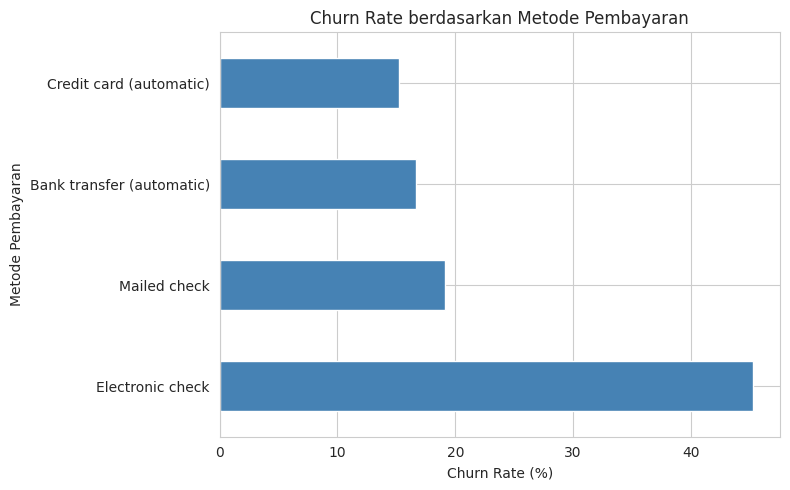

In [ ]:
plt.figure(figsize=(8, 5))
churn_per_pembayaran.plot(kind='barh', color='steelblue')
plt.title('Churn Rate berdasarkan Metode Pembayaran')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Metode Pembayaran')
plt.tight_layout()
plt.show()

**INSIGHT Pertanyaan 2:**
**Electronic check** punya churn rate paling tinggi dibanding metode pembayaran otomatis lain (bank transfer, credit card). Pelanggan yang churn lewat metode ini juga rata-rata punya CLTV yang perlu diperhatikan kalau CLTV mereka tinggi, kehilangan mereka artinya kehilangan potensi nilai jangka panjang yang besar.

**INSIGHT bisnis:** Dorong migrasi dari Electronic check ke metode pembayaran otomatis, terutama untuk pelanggan dengan CLTV tinggi.

## Pertanyaan 3: Bagaimana pola churn berdasarkan TenureGroup dan tren dari waktu ke waktu?

Teknik: **pivot_table**, **groupby**, dan **datetime manipulation**.

In [ ]:
pivot_tenure = pd.pivot_table(df, values='Churn Value', index='TenureGroup',
                               columns='Contract', aggfunc='mean', observed=False) * 100
pivot_tenure

Contract,Month-to-month,One year,Two year
TenureGroup,,,
0-12 bulan,51.354062,10.483871,0.000000
13-24 bulan,37.720488,8.121827,0.000000
25-48 bulan,32.917706,10.617761,2.189781
49-72 bulan,26.023392,12.933754,3.325416


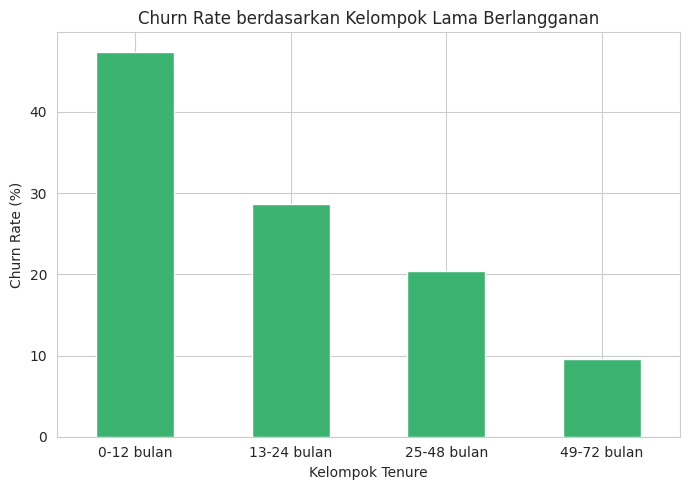

In [ ]:
churn_per_tenure_group = df.groupby('TenureGroup', observed=False)['Churn Value'].mean() * 100

plt.figure(figsize=(7, 5))
churn_per_tenure_group.plot(kind='bar', color='mediumseagreen')
plt.title('Churn Rate berdasarkan Kelompok Lama Berlangganan')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Kelompok Tenure')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

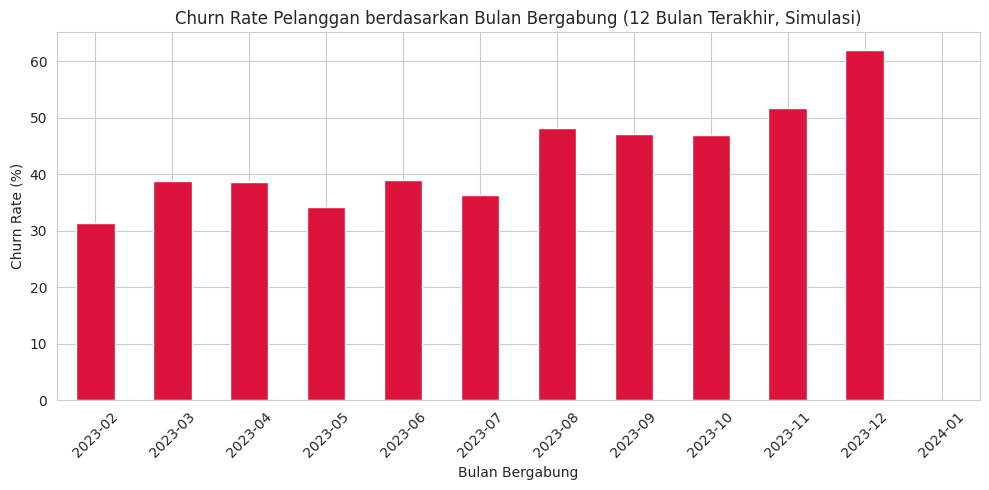

In [ ]:
# Tren churn rate berdasarkan bulan bergabung (simulasi JoinDate), 12 bulan terakhir
churn_per_bulan_join = df.groupby('JoinYearMonth', observed=False)['Churn Value'].mean().tail(12) * 100

plt.figure(figsize=(10, 5))
churn_per_bulan_join.plot(kind='bar', color='crimson')
plt.title('Churn Rate Pelanggan berdasarkan Bulan Bergabung (12 Bulan Terakhir, Simulasi)')
plt.xlabel('Bulan Bergabung')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**INSIGHT Pertanyaan 3:**
Churn rate paling tinggi ada di kelompok pelanggan baru (0-12 bulan) dan terus menurun seiring bertambahnya lama berlangganan. Dari sisi tren waktu (simulasi), pelanggan dengan tenure rendah (mendekati tanggal data ditarik) juga menunjukkan churn rate yang cenderung lebih tinggi, memperkuat insight yang sama.

**INSIGHT bisnis:** Fokuskan program retensi di 12 bulan pertama pelanggan baru, misalnya lewat check-in berkala atau penawaran khusus di fase awal berlangganan.

## Pertanyaan 4: Apakah jumlah layanan tambahan berhubungan dengan churn?

Teknik: **melt** dan **groupby**.

In [ ]:
df_melt = df.melt(id_vars=['CustomerID', 'Churn Label'],                  # melt untuk mengolah DataFrame ke dalam format di mana satu atau lebih kolom merupakan variabel pengenal.
                   value_vars=kolom_layanan,
                   var_name='JenisLayanan', value_name='StatusLayanan')

df_melt.head(10)

,CustomerID,Churn Label,JenisLayanan,StatusLayanan
0,3668-QPYBK,Yes,Online Security,Yes
1,9237-HQITU,Yes,Online Security,No
2,9305-CDSKC,Yes,Online Security,No
3,7892-POOKP,Yes,Online Security,No
4,0280-XJGEX,Yes,Online Security,No
5,4190-MFLUW,Yes,Online Security,No
6,8779-QRDMV,Yes,Online Security,No
7,1066-JKSGK,Yes,Online Security,No
8,6467-CHFZW,Yes,Online Security,No
9,8665-UTDHZ,Yes,Online Security,No


In [ ]:
df_melt['ChurnFlag'] = (df_melt['Churn Label'] == 'Yes').astype(int)

churn_per_layanan = df_melt[df_melt['StatusLayanan'] == 'Yes'].groupby('JenisLayanan')['ChurnFlag'].mean() * 100
churn_per_layanan = churn_per_layanan.sort_values()

churn_per_layanan

,ChurnFlag
JenisLayanan,
Online Security,14.611194
Tech Support,15.166341
Online Backup,21.531494
Device Protection,22.502064
Streaming Movies,29.941435
Streaming TV,30.070188


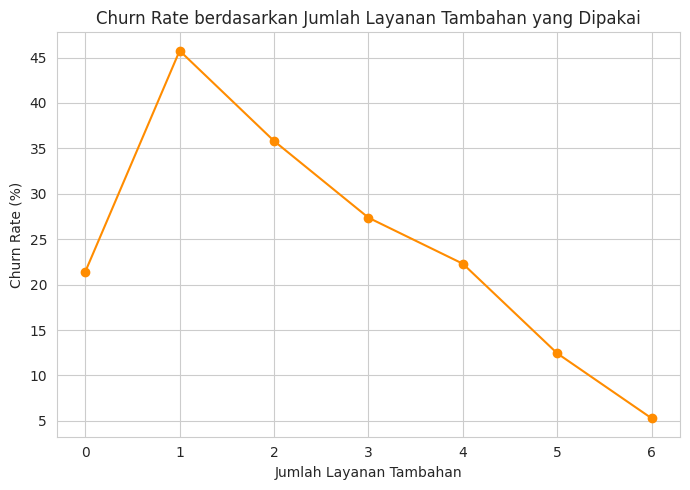

In [ ]:
churn_per_jumlah_layanan = df.groupby('JumlahLayananTambahan')['Churn Value'].mean() * 100

plt.figure(figsize=(7, 5))
churn_per_jumlah_layanan.plot(kind='line', marker='o', color='darkorange')
plt.title('Churn Rate berdasarkan Jumlah Layanan Tambahan yang Dipakai')
plt.xlabel('Jumlah Layanan Tambahan')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

**INSIGHT Pertanyaan 4:**
Makin banyak layanan tambahan yang dipakai, makin rendah churn rate-nya tren menurun yang jelas. Layanan **Tech Support** dan **Online Security** punya churn rate paling rendah dibanding layanan lain seperti Streaming TV/Movies.

**INSIGHT bisnis:** Dorong cross-selling Tech Support dan Online Security ke pelanggan baru untuk meningkatkan loyalitas.

## Pertanyaan 5: Apa alasan utama pelanggan churn, dan hubungannya dengan CLTV serta kota asal?

Teknik: **filtering**, **groupby**, **sorting**, dan **crosstab**.

In [ ]:
# Filtering: fokus cuma ke pelanggan yang benar-benar churn
pelanggan_churn = df[df['Churn Label'] == 'Yes']

# Kelompok alasan churn yang paling sering muncul, diurutkan (sorting)
alasan_churn = pelanggan_churn['ChurnReasonGroup'].value_counts().sort_values(ascending=False)
alasan_churn

,count
ChurnReasonGroup,
Kompetitor,621
Layanan/Sikap Staff,587
Kualitas Produk/Jaringan,205
Lainnya,204
Harga,199
Pindah Domisili,53


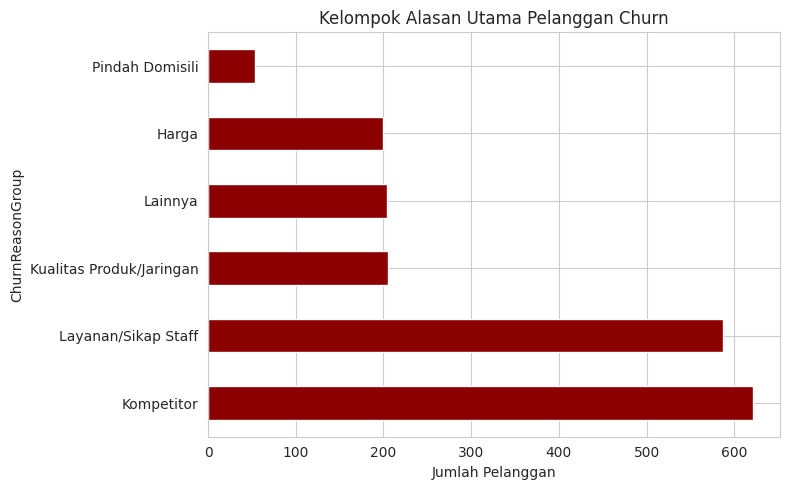

In [ ]:
plt.figure(figsize=(8, 5))
alasan_churn.plot(kind='barh', color='darkred')
plt.title('Kelompok Alasan Utama Pelanggan Churn')
plt.xlabel('Jumlah Pelanggan')
plt.tight_layout()
plt.show()

In [ ]:
# Rata-rata CLTV pelanggan churn per kelompok alasan (groupby + sorting)
cltv_per_alasan = pelanggan_churn.groupby('ChurnReasonGroup')['CLTV'].mean().sort_values(ascending=False)
cltv_per_alasan

,CLTV
ChurnReasonGroup,
Kompetitor,4179.864734
Layanan/Sikap Staff,4163.809199
Kualitas Produk/Jaringan,4142.765854
Harga,4127.889447
Lainnya,4125.931373
Pindah Domisili,3830.132075


In [ ]:
# Top 10 kota dengan jumlah pelanggan churn terbanyak (filtering + groupby + sorting)
churn_per_kota = pelanggan_churn.groupby('City').size().sort_values(ascending=False).head(10)
churn_per_kota

,0
City,
Los Angeles,90
San Diego,50
San Francisco,31
San Jose,29
Sacramento,26
Fresno,16
Long Beach,15
Glendale,13
Oakland,13


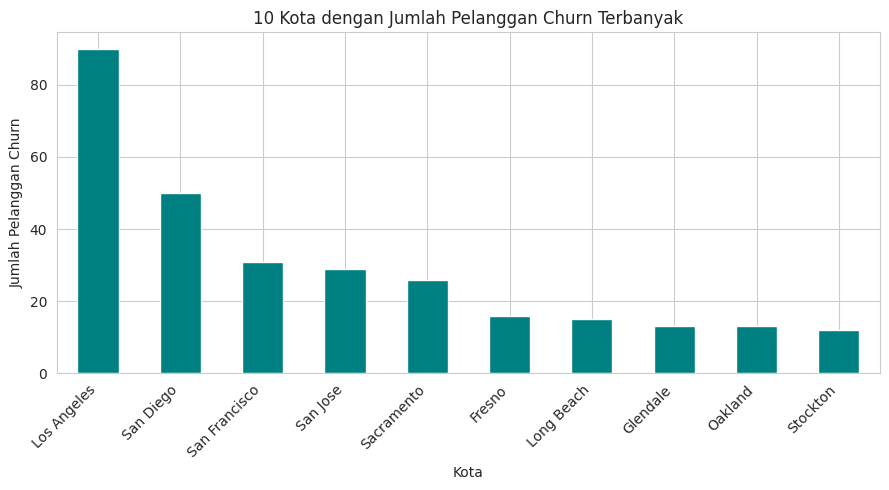

In [ ]:
plt.figure(figsize=(9, 5))
churn_per_kota.plot(kind='bar', color='teal')
plt.title('10 Kota dengan Jumlah Pelanggan Churn Terbanyak')
plt.ylabel('Jumlah Pelanggan Churn')
plt.xlabel('Kota')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**INSIGHT Pertanyaan 5:**
Alasan churn terbanyak berasal dari faktor **Kompetitor** (kompetitor menawarkan harga/kecepatan/device yang lebih baik), diikuti oleh **Layanan/Sikap Staff**. Ini artinya layanan kalah bersaing di pasar dan faktor pengalaman layanan pelanggan.

Dari sisi CLTV, kelompok alasan tertentu punya rata-rata CLTV yang lebih tinggi artinya pelanggan yang hilang karena alasan itu adalah pelanggan yang secara nilai jangka panjang lebih berharga, sehingga perlu diprioritaskan dalam strategi retensi.

Secara geografis, churn terpusat di kota-kota besar seperti Los Angeles dan San Diego karena populasi pelanggan di kota tersebut juga paling banyak, bisa jadi sinyal untuk fokus strategi retensi regional di kota-kota tersebut.

**INSIGHT bisnis:**
- Perkuat proposisi harga dan kualitas jaringan untuk melawan tekanan kompetitor.
- Lakukan pelatihan customer service untuk memperbaiki sikap staff pendukung, karena ini jadi alasan churn signifikan kedua.
- Prioritaskan program retensi untuk pelanggan dengan CLTV tinggi yang berada dalam kelompok alasan churn berisiko.
- Tinjau kualitas layanan di kota-kota dengan jumlah churn tertinggi.



---


## E. Correlation Heatmap (Multivariate Output)

In [ ]:
kolom_numerik = ['Tenure Months', 'Monthly Charges', 'Total Charges',
                  'CLTV', 'Churn Score', 'JumlahLayananTambahan', 'Churn Value']

matriks_korelasi = df[kolom_numerik].corr()
matriks_korelasi

,Tenure Months,Monthly Charges,Total Charges,CLTV,Churn Score,JumlahLayananTambahan,Churn Value
Tenure Months,1.000000,0.247900,0.826178,0.396406,-0.224987,0.494263,-0.352229
Monthly Charges,0.247900,1.000000,0.651174,0.098693,0.133754,0.724706,0.193356
Total Charges,0.826178,0.651174,1.000000,0.342091,-0.123410,0.744827,-0.198324
CLTV,0.396406,0.098693,0.342091,1.000000,-0.079782,0.187162,-0.127463
Churn Score,-0.224987,0.133754,-0.123410,-0.079782,1.000000,-0.057931,0.664897
JumlahLayananTambahan,0.494263,0.724706,0.744827,0.187162,-0.057931,1.000000,-0.087698
Churn Value,-0.352229,0.193356,-0.198324,-0.127463,0.664897,-0.087698,1.000000


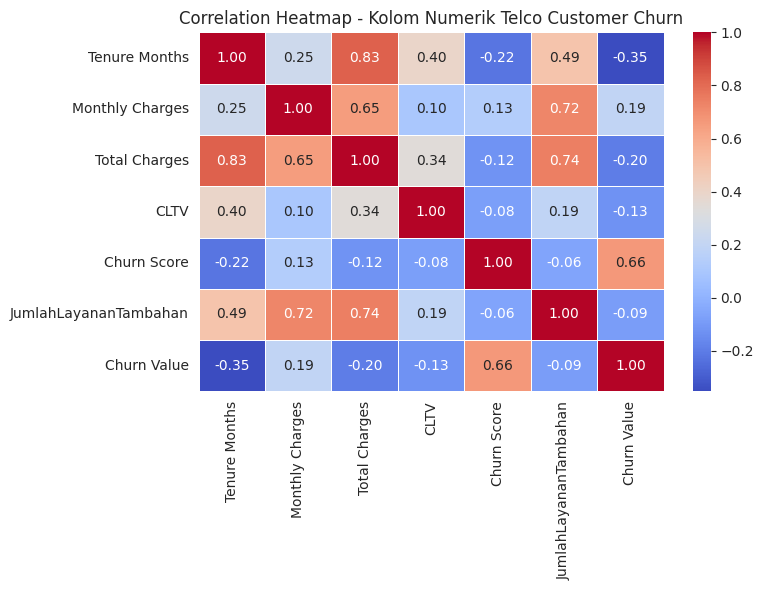

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(matriks_korelasi, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - Kolom Numerik Telco Customer Churn')
plt.tight_layout()
plt.show()

**Interpretasi Correlation Heatmap:**
- `Tenure Months` dan `Total Charges` berkorelasi positif sangat kuat, makin lama berlangganan, makin besar akumulasi tagihan.
- `Churn Score` (skor risiko churn dari sistem) berkorelasi **positif kuat** dengan `Churn Value`.
- `Tenure Months` dan `JumlahLayananTambahan` berkorelasi **negatif** dengan `Churn Value`, konsisten dengan insight di Pertanyaan 3 dan 4.
- `Monthly Charges` berkorelasi **positif** dengan `Churn Value`, pelanggan dengan tagihan bulanan lebih besar sedikit lebih rawan churn.
- `CLTV` tidak berkorelasi kuat secara linear dengan `Churn Value`, artinya nilai pelanggan jangka panjang tidak serta-merta menentukan siapa yang akan churn. Pelanggan bernilai tinggi maupun rendah sama-sama punya risiko churn tersendiri.



---


## F. Kesimpulan & Rekomendasi Bisnis

1. **Jenis kontrak** adalah faktor paling berpengaruh terhadap churn, kontrak bulanan jauh lebih rawan.
2. **Metode pembayaran manual** (Electronic check) berhubungan dengan churn rate lebih tinggi dibanding metode otomatis.
3. **Pelanggan baru** (tenure di bawah 12 bulan) adalah segmen paling rawan churn.
4. **Layanan tambahan**, terutama Tech Support dan Online Security, berkorelasi dengan churn rate yang lebih rendah.
5. **Alasan churn** didominasi oleh faktor kompetitor dan sikap layanan staff bukan cuma soal produk semata.
6. `Churn Score` bawaan sistem terbukti valid (berkorelasi kuat dengan churn aktual), sedangkan `CLTV` tidak otomatis melindungi pelanggan dari risiko churn.

**Rekomendasi untuk tim bisnis:**
- Fokuskan program retensi pada pelanggan baru dengan kontrak bulanan, kombinasi segmen paling berisiko.
- Tawarkan insentif migrasi ke kontrak tahunan dan metode pembayaran otomatis.
- Dorong cross-selling Tech Support dan Online Security untuk meningkatkan stickiness pelanggan.
- Perkuat daya saing harga/jaringan dan tingkatkan kualitas layanan pelanggan untuk menekan churn akibat faktor kompetitor dan sikap staff.
- Prioritaskan retensi pelanggan dengan CLTV tinggi yang masuk kelompok alasan churn berisiko, karena kehilangan mereka berdampak lebih besar ke bisnis jangka panjang.